In [3]:
import numpy as np
import matplotlib.pylab as plt

In [33]:
i = 2
n = 4
gamma = 5.0
Ne = 10000

#x0 = 0.4
#x0 = 1/(2*Ne)
#print(x0)

rng = np.random.default_rng()
# Desired mean
m = 0.4
k = 10
a = m * k
b = (1 - m) * k
x0 = rng.beta(a, b, size=10000)
m2 = np.var(x0)

print(a,b)

var_formula = (a * b)/(((a + b)**2)*(a + b + 1) )


#Set to beta distribution with mean 0.4 so the variance is not the same
m1 = np.mean(x0)
#h2 = x0 * (1 - x0)
h2 = np.mean(x0 * (1 - x0)) 
h3 = np.mean(h2 * (1 - 2 * x0))

print(m1, m2, var_formula, h2)


time_step = 1/(2*Ne)
t_max = 1
num_steps = int(t_max / time_step)

times = np.zeros(num_steps + 1)
m1_vals = np.zeros(num_steps + 1)
h2_vals = np.zeros(num_steps + 1)
h3_vals = np.zeros(num_steps + 1)

m1_vals[0] = m1
h2_vals[0] = h2
h3_vals[0] = h3

# Likelihood
logZ = 0.0
logZ_vals = np.zeros(num_steps + 1)
logZ_vals[0] = logZ

for step in range(1, num_steps + 1):
    t = step * time_step

    # Closure for H3
    h3 = h2 * (1 - 2 * m1)
    #Change

    dm1_dt = (i - n * m1) + gamma * h2 + gamma * n * (m1 * (1 - m1) - h2)

    dh2_dt = (
        i
        - m1 * (2 * i - n)
        - h2 * (1 + 2 * n - gamma * n * (0.5 - m1))
        + h3 * (gamma - gamma * n / 2)
    )

    dlogZ_dt = - (n * (n - 1) / 2) + gamma * (i - n * m1)
    
    logZ += time_step * dlogZ_dt
    m1 += time_step * dm1_dt
    h2 += time_step * dh2_dt

    m1 = min(max(m1, 0.0), 1.0)
    h2 = max(h2, 0.0)

    h3 = h2 * (1 - 2 * m1)

    times[step] = t
    m1_vals[step] = m1
    h2_vals[step] = h2
    h3_vals[step] = h3
    logZ_vals[step] = logZ


# Conditional stationary distribution

x_grid = np.linspace(1e-6, 1 - 1e-6, 5000)

v_cond_unnorm = (
    x_grid ** (2 * i - 1)
    * (1 - x_grid) ** (2 * (n - i) - 1)
    * np.exp(2 * gamma * x_grid)
)

Z = np.trapz(v_cond_unnorm, x_grid)
v_cond = v_cond_unnorm / Z

# Stationary moments
m1_stationary = np.trapz(x_grid * v_cond, x_grid)

4.0 6.0
0.40322565243218267 0.022350510666772818 0.02181818181818182 0.2182842149860505


/var/folders/tp/hnddtc311jb72wx_xwvrc6nr0000gr/T/ipykernel_42249/3031148015.py:95: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  Z = np.trapz(v_cond_unnorm, x_grid)
/var/folders/tp/hnddtc311jb72wx_xwvrc6nr0000gr/T/ipykernel_42249/3031148015.py:99: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  m1_stationary = np.trapz(x_grid * v_cond, x_grid)


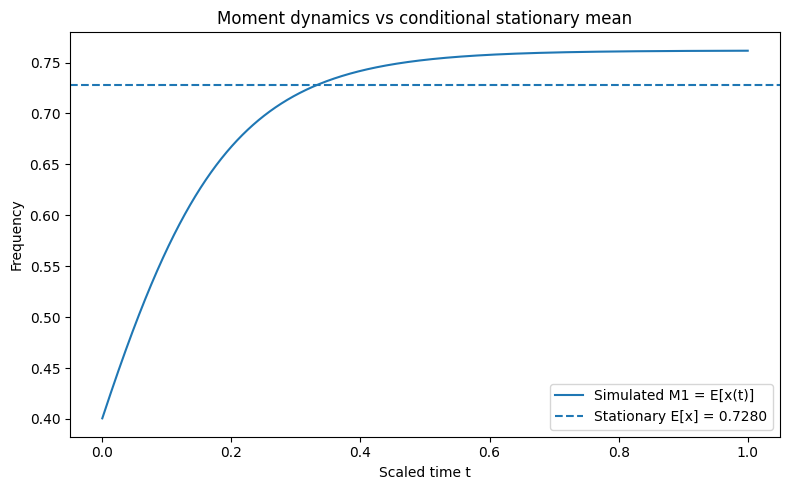

Final M1: 0.761597
Final H2: 0.172233
Final H3: -0.090111

Final simulated moments:
Final M1: 0.761597


In [28]:
plt.figure(figsize=(8, 5))
plt.plot(times, m1_vals, label="Simulated M1 = E[x(t)]")
plt.axhline(
    m1_stationary,
    linestyle="--",
    label=f"Stationary E[x] = {m1_stationary:.4f}"
)
plt.xlabel("Scaled time t")
plt.ylabel("Frequency")
plt.title("Moment dynamics vs conditional stationary mean")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Final M1: {m1_vals[-1]:.6f}")
print(f"Final H2: {h2_vals[-1]:.6f}")
print(f"Final H3: {h3_vals[-1]:.6f}")
print("\nFinal simulated moments:")
print(f"Final M1: {m1_vals[-1]:.6f}")

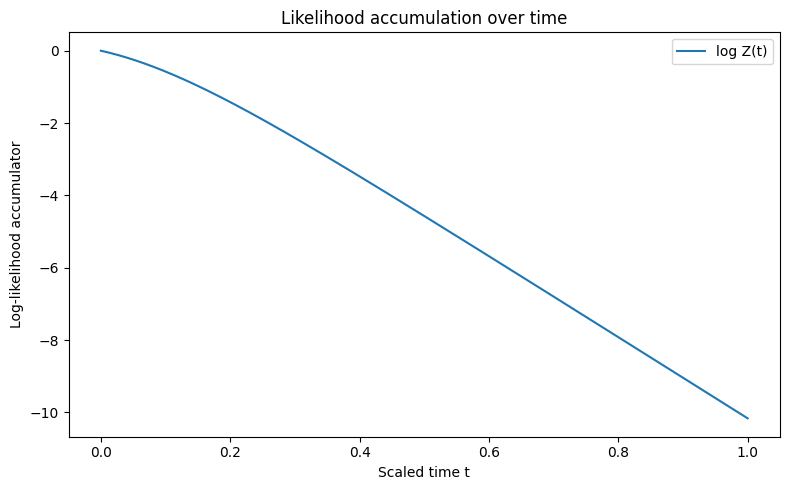

In [29]:
plt.figure(figsize=(8, 5))
plt.plot(times, logZ_vals, label="log Z(t)")
plt.xlabel("Scaled time t")
plt.ylabel("Log-likelihood accumulator")
plt.title("Likelihood accumulation over time")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Confirm its converging to the right thing

# stationary density

#Add likelihood

In [ ]:
# COmpute H2 and H3 analytically

#Compare this H3 to the one obtained using the beta Closure Cdynamic approach. For initialization, they should be the same

# Also close the moments dynamically

In [37]:
i = 2
n = 4
gamma = 5.0
Ne = 10000

a = 4
b = 6

m1 = a / (a + b)
h2 = (a * b) / ((a + b) * (a + b + 1))
h3 = (a * b * (b - a)) / ((a + b) * (a + b + 1) * (a + b + 2))

print(m1, h2, h3)


time_step = 1/(2*Ne)
t_max = 1
num_steps = int(t_max / time_step)

times = np.zeros(num_steps + 1)
m1_vals = np.zeros(num_steps + 1)
h2_vals = np.zeros(num_steps + 1)
h3_vals = np.zeros(num_steps + 1)
C_vals = np.zeros(num_steps + 1)

m1_vals[0] = m1
h2_vals[0] = h2
h3_vals[0] = h3

# Likelihood
logZ = 0.0
logZ_vals = np.zeros(num_steps + 1)
logZ_vals[0] = logZ

for step in range(1, num_steps + 1):
    t = step * time_step

    dm1_dt = (i - n * m1) + gamma * h2 + gamma * n * (m1 * (1 - m1) - h2)

    dh2_dt = (
        i
        - m1 * (2 * i - n)
        - h2 * (1 + 2 * n - gamma * n * (0.5 - m1))
        + h3 * (gamma - gamma * n / 2)
    )

    dlogZ_dt = - (n * (n - 1) / 2) + gamma * (i - n * m1)
    
    logZ += time_step * dlogZ_dt
    m1 += time_step * dm1_dt
    h2 += time_step * dh2_dt

    #m1 = min(max(m1, 0.0), 1.0)
    #h2 = max(h2, 0.0)

    #h3 = h2 * (1 - 2 * m1)
    # Closure for H3
    denom = m1 * (1 - m1) - h2

    if denom <= 1e-12:
        C_dynamic = np.inf
        h3 = h2 * (1 - 2 * m1)   # fallback
    else:
        C_dynamic = h2 / denom
        h3 = h2 * (1 - 2 * m1) * (C_dynamic / (C_dynamic + 2))
    #h3 = h2 * (1 - 2 * m1)

    times[step] = t
    m1_vals[step] = m1
    h2_vals[step] = h2
    h3_vals[step] = h3
    C_vals[step] = C_dynamic if np.isfinite(C_dynamic) else np.nan
    logZ_vals[step] = logZ


# Conditional stationary distribution

x_grid = np.linspace(1e-6, 1 - 1e-6, 5000)

v_cond_unnorm = (
    x_grid ** (2 * i - 1)
    * (1 - x_grid) ** (2 * (n - i) - 1)
    * np.exp(2 * gamma * x_grid)
)

Z = np.trapezoid(v_cond_unnorm, x_grid)
v_cond = v_cond_unnorm / Z

# Stationary moments
m1_stationary = np.trapezoid(x_grid * v_cond, x_grid)

0.4 0.21818181818181817 0.03636363636363636


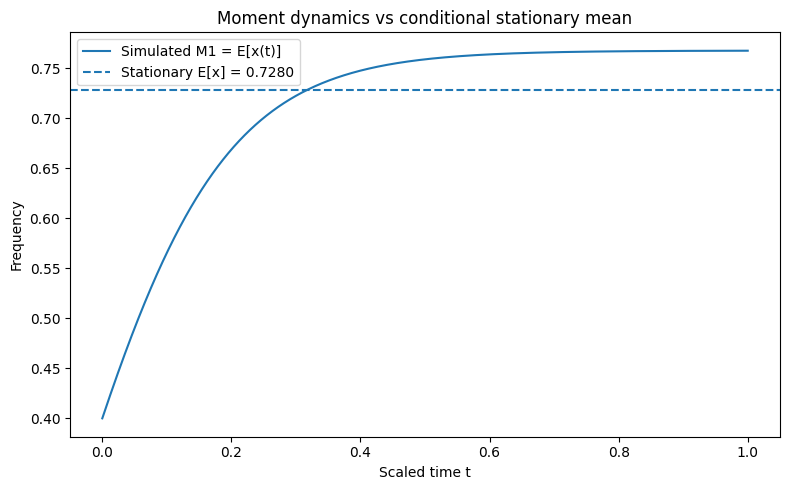

Final M1: 0.767427
Final H2: 0.166589
Final H3: -0.077967

Final simulated moments:
Final M1: 0.767427


In [38]:
plt.figure(figsize=(8, 5))
plt.plot(times, m1_vals, label="Simulated M1 = E[x(t)]")
plt.axhline(
    m1_stationary,
    linestyle="--",
    label=f"Stationary E[x] = {m1_stationary:.4f}"
)
plt.xlabel("Scaled time t")
plt.ylabel("Frequency")
plt.title("Moment dynamics vs conditional stationary mean")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Final M1: {m1_vals[-1]:.6f}")
print(f"Final H2: {h2_vals[-1]:.6f}")
print(f"Final H3: {h3_vals[-1]:.6f}")
print("\nFinal simulated moments:")
print(f"Final M1: {m1_vals[-1]:.6f}")

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(times, logZ_vals, label="log Z(t)")
plt.xlabel("Scaled time t")
plt.ylabel("Log-likelihood accumulator")
plt.title("Likelihood accumulation over time")
plt.legend()
plt.tight_layout()
plt.show()